Approximation with step size 0.01:
Average y value: 1.9101617792186754
Average error: -0.3690162712706905
Data point closest to x=15: (15.002830246369596, 0.2324896386610591)

Approximation with step size 0.05:
Average y value: 1.0178220080606892
Average error: -1.2597289774195177
Data point closest to x=15: (15.007608217785636, 0.12131231300557774)

Approximation with step size 0.10:
Average y value: 0.5377260346485454
Average error: -1.73779709212455
Data point closest to x=15: (15.007608217785636, 0.05192571518881656)

Approximation with step size 0.15:
Average y value: 0.3197819117220568
Average error: -1.953710127269553
Data point closest to x=15: (15.03154379708035, 0.021963222795461056)

Approximation with step size 0.20:
Average y value: 0.20447268245849218
Average error: -2.0670139787235495
Data point closest to x=15: (15.007608217785636, 0.007995379767749037)

Approximation with step size 0.25:
Average y value: 0.13579747480359125
Average error: -2.133632388625047
Data point 

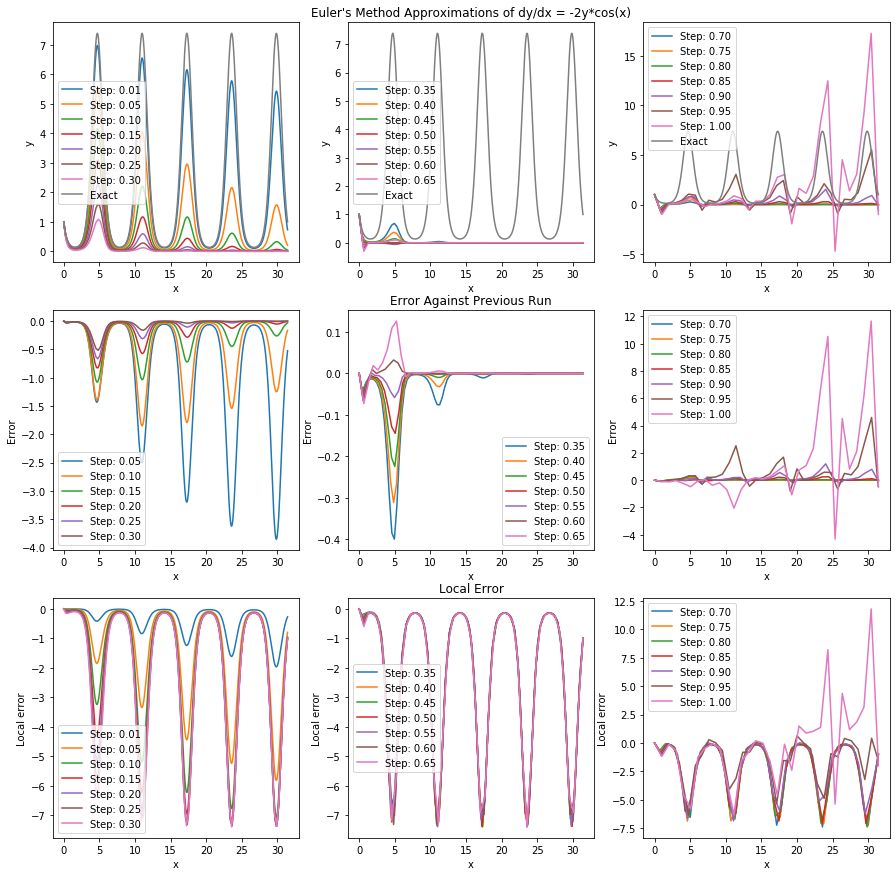

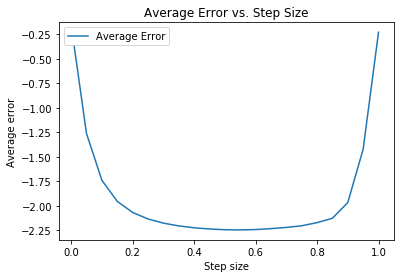

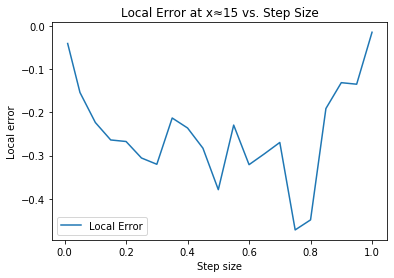

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline


X_START = 0.0
X_END = 10.0*np.pi
STEPS_PER_PLOT = 7


def dy_dx(x, y):
    """Function representing dy/dx = -2y*cos(x)"""
    return -2.0 * y * np.cos(x)


def f(x):
    """Specific solution of above function, initial condition y(0)=1"""
    return np.exp(-2.0 * np.sin(x))


def f_error(y_approx, y_exact):
    """Compute local and average error of solution of y values"""
    err = y_approx - y_exact
    return err, np.mean(err)


def get_x_values(h):
    """Get x values for a range with step size h"""
    num_steps = int((X_END - X_START) / h) + 1
    return np.linspace(X_START, X_END, num_steps, dtype=float)


def configure_subplots(subplots, title, ylabel):
    for j, subp in enumerate(subplots):
        subp.set_xlabel('x')
        subp.set_ylabel(ylabel)
        subp.legend()
        if j == len(subplots) // 2:  # centermost subplot
            subp.set_title(title)


# Setup step sizes and error arrays
h = np.arange(0.0, 1.01, 0.05, dtype=float)
h[0] = 0.01
errs_avg = np.zeros(h.size)
errs_local_15 = np.zeros(h.size)

# Setup plot of approximations
plt.figure(figsize=[15.0, 15.0])  # extra-wide figure
num_subplots = h.size // STEPS_PER_PLOT + (1 if h.size % STEPS_PER_PLOT != 0 else 0)
subplots = [[plt.subplot(3, num_subplots, 1+j+i*num_subplots) for j in range(num_subplots)] for i in range(3)]

# Plot Euler's method approximations
values_prev = None
for i, s in enumerate(h):
    # Initial condition
    x_values = get_x_values(s)
    y_values = np.zeros(x_values.size, dtype=float)
    y_values[0] = 1.0  # y(0) = 1

    # Implement Euler's method
    for j in range(x_values.size - 1):
        y_values[j + 1] = y_values[j] + s * dy_dx(x_values[j], y_values[j])

    # Calculate local/average error
    y_exact = f(x_values)
    err_local, err_avg = f_error(y_values, y_exact)

    # Record average error
    errs_avg[i] = err_avg

    # Record local error at x approx. 15
    i_15 = round((x_values.size-1)*(15.0-X_START)/(X_END-X_START))
    errs_local_15[i] = err_local[i_15]

    # Calculate error against previous run
    err_prev = None
    if values_prev is not None:
        cs = CubicSpline(values_prev[0], values_prev[1], bc_type='natural')
        y_values_prev_interp = cs(x_values)
        err_prev = y_values - y_values_prev_interp
    values_prev = (x_values, y_values)

    # Plot the results
    i_subp = (i // STEPS_PER_PLOT)
    subplots[0][i_subp].plot(x_values, y_values, label=f"Step: {s:.2f}")
    if err_prev is not None:
        subplots[1][i_subp].plot(x_values, err_prev, label=f"Step: {s:.2f}")
    subplots[2][i_subp].plot(x_values, err_local, label=f"Step: {s:.2f}")

    # Output stats
    print(f"Approximation with step size {s:.2f}:")
    print("Average y value:", np.mean(y_values))
    print("Average error:", err_avg)
    print(f"Data point closest to x=15: ({x_values[i_15]}, {y_values[i_15]})")
    # print("Local error:", err_local)
    print()

# Plot exact solution
x0 = get_x_values(h[0])
y0 = f(x0)
for j, subp in enumerate(subplots[0]):
    subp.plot(x0, y0, label="Exact")

# Configure and show plot of approximations
configure_subplots(subplots[0], "Euler's Method Approximations of dy/dx = -2y*cos(x)", 'y')
configure_subplots(subplots[1], "Error Against Previous Run", 'Error')
configure_subplots(subplots[2], "Local Error", 'Local error')
plt.show()

# Plot average error vs. step size
plt.plot(h, errs_avg, label="Average Error")
plt.xlabel('Step size')
plt.ylabel('Average error')
plt.title("Average Error vs. Step Size")
plt.legend()
plt.show()

# Plot local error at x≈15 vs. step size
plt.plot(h, errs_local_15, label="Local Error")
plt.xlabel('Step size')
plt.ylabel('Local error')
plt.title("Local Error at x≈15 vs. Step Size")
plt.legend()
plt.show()


We can see in the Euler's Method Approximation and Local Error plots above that the plots of the smaller step sizes (h<0.35) tend to have the least error at the beginning, but then drift and progressively become closer to 0 as x gets larger. The overall amplitude tends to increase as step size decreases. The plots of the middle step sizes (0.35<h<0.9) are generally flat and do not change much at all as x increases. The plots of the larger step sizes (h>0.9) appear to do the opposite of the smaller step sizes, where they start small and become larger as x increases. Because step size is so large, these plots appear unstable. In particular, the plot with step size h=1.0 has the points with the greatest magnitude of error out of any plot despite having the smallest average error overall.

The plots of Average Error vs. Step Size and Local Error at x≈15 vs. Step Size both corroborate this trend. The step sizes closer to both 0 and 1 result in smaller average errors than step sizes in the middle of the range. This is likely due to the fact that the exact solution to the differential equation is oscillating. Because each step of the Euler's method calculation completely skips over values between steps, it is possible for it to work on an interval that skips over parts with high rates of change, resulting in a plot that is flat overall but may periodically align with the exact solution. Additionally, small step sizes will usually be more stable than large step sizes because they have smaller amounts of change between each step.

To do a stability analysis on `dy/dx = -2y*cos(x)`, we plug it into the Euler's method equation and solve for the growth factor and stability condition:

```
y_(n+1) = y_n + h(-2y_n*cos(x_n))

y_(n+1) = y_n(1 - 2h*cos(x_n))

y_1 = y_0(1 - 2h*cos(x_0))
y_2 = y_1(1 - 2h*cos(x_1)) = y_0(1 - 2h*cos(x_0))(1 - 2h*cos(x_1))
...and so on
```

Lambda: `-2cos(x)`
Growth factor: `|1 - 2h*cos(x)|`
Stability condition: `|1 - 2h*cos(x)| <= 1`

In order for any given step of the Euler's method solution to decrease or remain constant from the previous step (suggests convergence) instead of increasing (suggests divergence), this stability condition must be met at the x position of that step. By extension, if the growth factor converges to a value that satisfies the stability condition as x goes to infinity, then this means that the Euler's method solution to the function will eventually become stable and converge.

The growth factor for `dy/dx = -2y*cos(x)` will not converge as x goes to infinity because it oscillates indefinetely. Therefore, it is never stable regardless of step size, and neither is any other oscillating differential equation. This implies that Euler's method will struggle to model any oscillating differential equation.